# 16 — MTL Tanpa Subtask SLD

**Motivasi**: Dari semua eksperimen MTL sebelumnya, subtask SLD (Sentiment Lexicon Detection) konsisten memiliki loss tertinggi dan konvergensi paling lambat. Subtask ini menggunakan lexicon statis yang hanya mencakup ~29% token, sehingga diduga menyuntikkan noise ke cross-attention.

**Notebook ini**:
1. **Part 1 — Bridging Analysis**: Membuktikan SLD adalah bottleneck di semua skenario MTL
2. **Part 2 — Arsitektur Baru**: `MTLNoSLDABSA` — ganti `sld_proj` dengan `asd_proj` (direct dari BERT)
3. **Part 3 — Training**: Single-phase, 50 epoch, patience=10 (sama dengan NB10)
4. **Part 4 — Evaluasi**: Perbandingan dengan NB10 MT+SLD dan ST

**Perubahan arsitektur inti**:
```
NB03: CrossAttention(query=h_ae, key/value=h_sl)   ← h_sl dari SLD projection
NB16: CrossAttention(query=h_ae, key/value=h_al)   ← h_al dari BERT langsung (asd_proj)
Loss NB03: λ1*(L_ATE + L_SLD) + λ2*L_ASD + L_CRF
Loss NB16: λ1*L_ATE             + λ2*L_ASD + L_CRF
```

In [1]:
import json
import os
import string
import time
import gc
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torchcrf import CRF
from seqeval.metrics import classification_report, f1_score as seq_f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.0 GB


In [2]:
# Paths
BASE_DIR = os.path.dirname(os.getcwd())
DATA_RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

BIEOS_PATH          = os.path.join(DATA_PROC_DIR, 'train_data_bieos.json')
BIEOS_AUG_TRAIN_PATH = os.path.join(DATA_PROC_DIR, 'train_data_bieos_augmented_train.json')
BIEOS_AUG_VAL_PATH   = os.path.join(DATA_PROC_DIR, 'train_data_bieos_val.json')
POS_LEX_PATH = os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_positive.tsv')
NEG_LEX_PATH = os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_negative.tsv')

# Model
MODEL_NAME = 'indobenchmark/indobert-large-p2'
MAX_LENGTH = 128
PROJ_DIM = 256

# Training (sama dengan NB10)
BATCH_SIZE = 4
GRADIENT_ACCUMULATION = 4
NUM_EPOCHS = 50
PATIENCE = 10
LR_BERT = 2e-5
LR_HEAD = 1e-4
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
TRAIN_RATIO = 0.85
SEED = 42

# Architecture
DROPOUT = 0.1
LAMBDA1 = 0.3
LAMBDA2 = 0.3
MAX_REL_POS = 20
IGNORE_INDEX = -100

# Reference results (dari NB10)
PRIOR_RESEARCH_F1 = 0.6761
NB03_MT_F1 = 0.7410
NB07_ST_F1 = 0.7551
NB10_MT_ORIG_F1 = 0.7578
NB10_ST_ORIG_F1 = 0.7558
NB10_MT_AUG_F1  = 0.7442
NB10_ST_AUG_F1  = 0.7600

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Model   : {MODEL_NAME}')
print(f'Epochs  : {NUM_EPOCHS} (patience={PATIENCE})')
print(f'Loss    : λ1*L_ATE + λ2*L_ASD + L_CRF  (SLD dihapus)')
print(f'λ1={LAMBDA1}, λ2={LAMBDA2}')

Model   : indobenchmark/indobert-large-p2
Epochs  : 50 (patience=10)
Loss    : λ1*L_ATE + λ2*L_ASD + L_CRF  (SLD dihapus)
λ1=0.3, λ2=0.3


---
## PART 1 — Bridging Analysis: SLD sebagai Bottleneck

Load semua checkpoint MTL dari NB03, NB06, NB08, NB09, NB10, NB12, dan NB13 (MTL variants), lalu ekstrak per-subtask loss history untuk membuktikan SLD konsisten menjadi subtask dengan loss tertinggi.

| Checkpoint | Notebook | Keterangan |
|-----------|----------|-----------|
| `checkpoint_final.pt` | NB03 | MT baseline, 18 ep |
| `checkpoint_v3.pt` | NB06 | MT + aug + freeze 12 layers |
| `checkpoint_tuning_v2.pt` | NB08 | 4 skenario λ |
| `checkpoint_multiseed.pt` | NB09 | 3 seeds MT |
| `checkpoint_extended_training.pt` | NB10 | MT 50ep |
| `checkpoint_base_model.pt` | NB12 | MT indobert-base-p2 (orig & aug) |
| `checkpoint_mtl_variants.pt` | NB13 | 4 varian arsitektur MTL |

> **Catatan**: NB11 (ablation) MT-nya reuse data dari NB10 (nilai identik). NB12 (base model comparison) menyimpan per-subtask loss untuk skenario MT (Original & Augmented) dengan model `indobert-base-p2`. NB13 punya per-subtask loss untuk semua 4 varian.

In [3]:
# Load semua checkpoint MTL
ckpt_nb03 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_final.pt'),
                       map_location='cpu', weights_only=False)
ckpt_nb06 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_v3.pt'),
                       map_location='cpu', weights_only=False)
ckpt_nb08 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_tuning_v2.pt'),
                       map_location='cpu', weights_only=False)
ckpt_nb09 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_multiseed.pt'),
                       map_location='cpu', weights_only=False)
ckpt_nb10 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_extended_training.pt'),
                       map_location='cpu', weights_only=False)
ckpt_nb12 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_base_model.pt'),
                       map_location='cpu', weights_only=False)
ckpt_nb13 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_mtl_variants.pt'),
                       map_location='cpu', weights_only=False)

# Kumpulkan semua skenario MTL ke format seragam
# Format: {'label': str, 'history': dict, 'best_epoch': int, 'best_f1': float, 'nb': str}
mt_scenarios = []

# NB03: baseline
h03 = ckpt_nb03['history']
be03 = h03['val_f1'].index(max(h03['val_f1'])) + 1
mt_scenarios.append({'label': 'NB03\nMT Baseline', 'history': h03,
                     'best_epoch': be03, 'best_f1': ckpt_nb03['best_f1'], 'nb': 'NB03'})

# NB06: augmented + freeze 12 layers
h06 = ckpt_nb06['history']
be06 = h06['val_f1'].index(max(h06['val_f1'])) + 1
mt_scenarios.append({'label': 'NB06\nMT+Aug+Freeze', 'history': h06,
                     'best_epoch': be06, 'best_f1': ckpt_nb06['best_f1'], 'nb': 'NB06'})

# NB08: 4 skenario lambda
for i, res in enumerate(ckpt_nb08['results']):
    h = res['history']
    be = h['val_f1'].index(max(h['val_f1'])) + 1
    lbl = res.get('name', f'S{i+1}')
    mt_scenarios.append({'label': f'NB08\n{lbl}', 'history': h,
                         'best_epoch': be, 'best_f1': res['best_f1'], 'nb': 'NB08'})

# NB09: 3 seeds
for res in ckpt_nb09['results']['multi_task']:
    h = res['history']
    be = h['val_f1'].index(max(h['val_f1'])) + 1
    mt_scenarios.append({'label': f'NB09\nSeed={res["seed"]}', 'history': h,
                         'best_epoch': be, 'best_f1': res['best_f1'], 'nb': 'NB09'})

# NB10: MT + Original (50 epoch)
h10_mt = ckpt_nb10['results']['MT + Original']['history']
be10 = h10_mt['val_f1'].index(max(h10_mt['val_f1'])) + 1
mt_scenarios.append({'label': 'NB10\nMT 50ep', 'history': h10_mt,
                     'best_epoch': be10, 'best_f1': ckpt_nb10['results']['MT + Original']['best_f1'],
                     'nb': 'NB10'})

# NB12: MT indobert-base-p2 (Original & Augmented)
for run_key, short_lbl in [('MT + Original', 'MT Orig'), ('MT + Augmented', 'MT Aug')]:
    res12 = ckpt_nb12['all_results'][run_key]
    h12 = res12['history']
    be12 = h12['val_f1'].index(max(h12['val_f1'])) + 1
    mt_scenarios.append({'label': f'NB12\n{short_lbl}', 'history': h12,
                         'best_epoch': be12, 'best_f1': res12['best_f1'], 'nb': 'NB12'})

# NB13: 4 varian arsitektur MTL
for name, res in ckpt_nb13['variant_results'].items():
    h = res['history']
    be = h['val_f1'].index(max(h['val_f1'])) + 1
    # Buat label singkat
    short = name.split(': ', 1)[-1] if ': ' in name else name
    mt_scenarios.append({'label': f'NB13\n{short}', 'history': h,
                         'best_epoch': be, 'best_f1': res['best_f1'], 'nb': 'NB13'})

print(f'Total skenario MTL: {len(mt_scenarios)}')
print()
for s in mt_scenarios:
    h = s['history']
    be = s['best_epoch'] - 1  # 0-indexed
    print(f"  {s['label'].replace(chr(10), ' '):<28}: "
          f"best_ep={s['best_epoch']:>2} F1={s['best_f1']:.4f} | "
          f"SLD={h['loss_sld'][be]:.3f}  ATE={h['loss_ate'][be]:.3f}  "
          f"ASD={h['loss_asd'][be]:.3f}  CRF={h['loss_crf'][be]:.3f}")

Total skenario MTL: 16

  NB03 MT Baseline            : best_ep=14 F1=0.7410 | SLD=0.325  ATE=0.009  ASD=0.023  CRF=0.065
  NB06 MT+Aug+Freeze          : best_ep= 7 F1=0.7341 | SLD=0.629  ATE=0.056  ASD=0.112  CRF=0.612
  NB08 A: Low Lambda (0.1)    : best_ep=11 F1=0.7332 | SLD=0.677  ATE=0.036  ASD=0.109  CRF=0.209
  NB08 B: Very Low Lambda (0.05): best_ep=10 F1=0.7379 | SLD=0.743  ATE=0.057  ASD=0.299  CRF=0.328
  NB08 C: No Phase 1 (λ=0.1)  : best_ep=18 F1=0.7328 | SLD=0.420  ATE=0.009  ASD=0.024  CRF=0.031
  NB08 D: Low Lambda + 25 Epochs: best_ep=14 F1=0.7409 | SLD=0.516  ATE=0.022  ASD=0.034  CRF=0.137
  NB09 Seed=42                : best_ep=15 F1=0.7413 | SLD=0.286  ATE=0.009  ASD=0.019  CRF=0.057
  NB09 Seed=123               : best_ep=10 F1=0.7266 | SLD=0.591  ATE=0.026  ASD=0.046  CRF=0.291
  NB09 Seed=456               : best_ep=15 F1=0.7277 | SLD=0.291  ATE=0.009  ASD=0.028  CRF=0.067
  NB10 MT 50ep                : best_ep=41 F1=0.7578 | SLD=0.003  ATE=0.001  ASD=0.001  CR

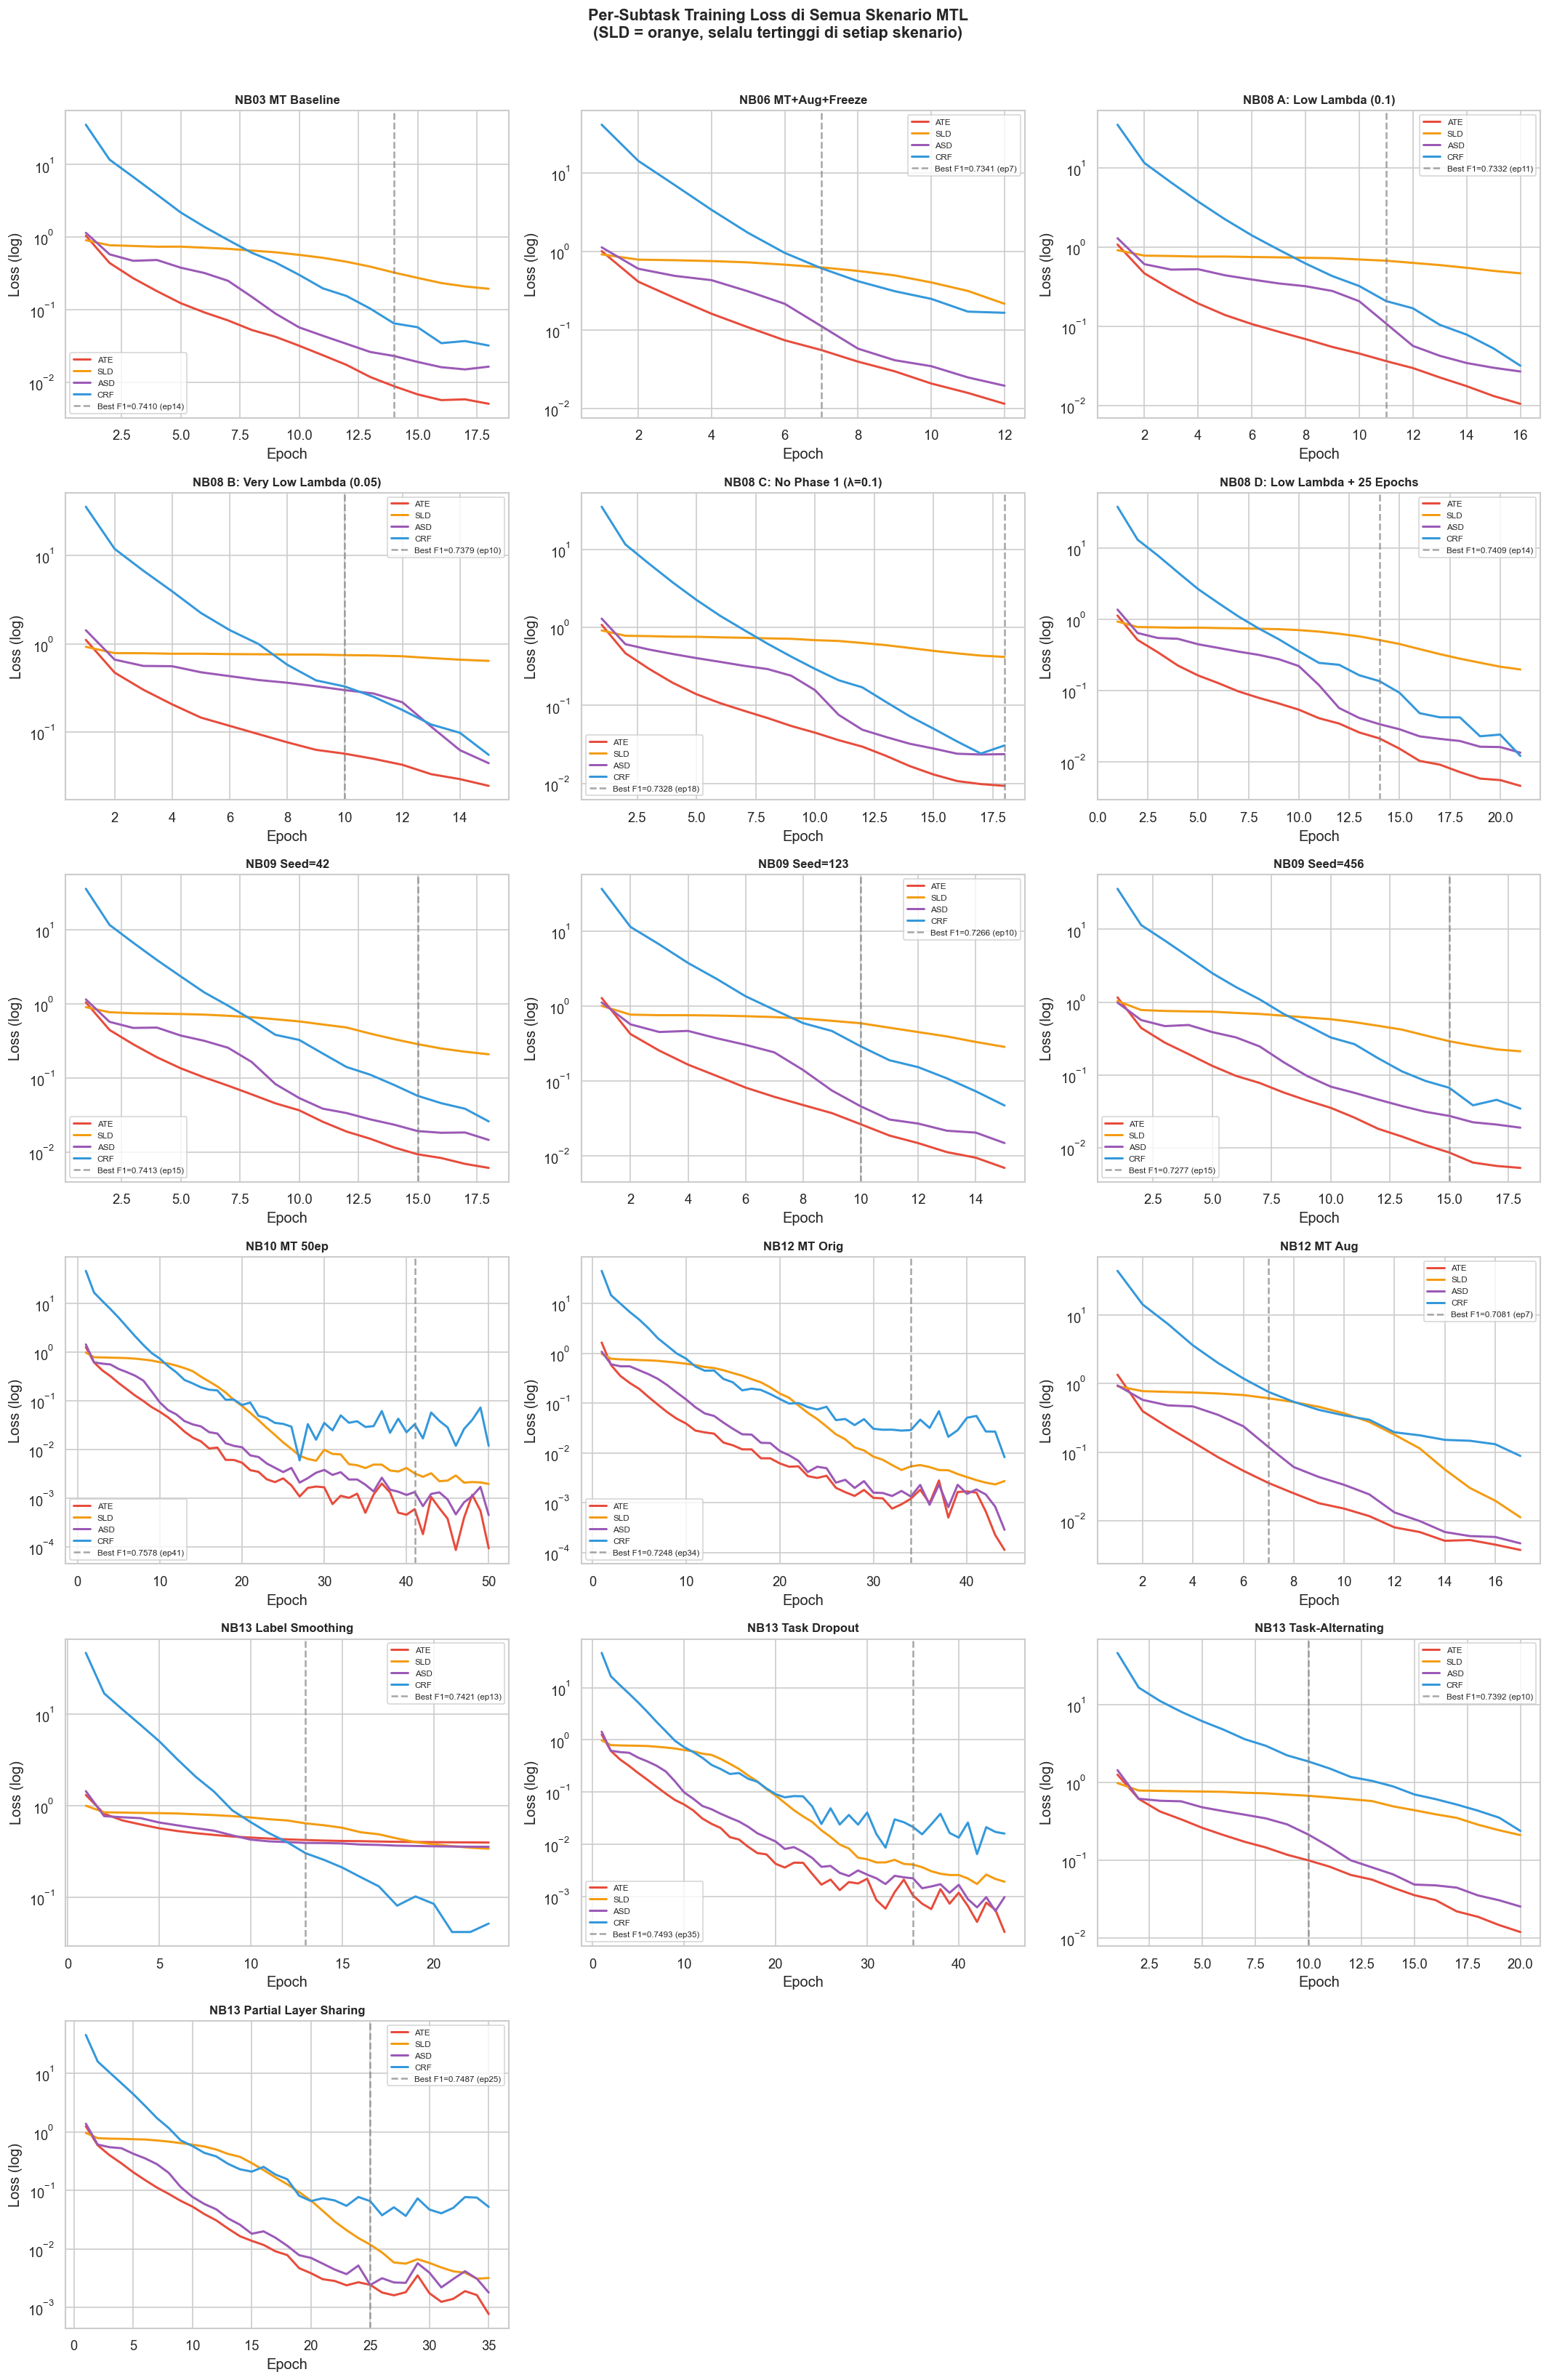

In [4]:
# Visualisasi per-subtask loss — semua skenario MTL
TASK_COLORS = {'ate': '#e74c3c', 'sld': '#f39c12', 'asd': '#9b59b6', 'crf': '#3498db'}
n_scenarios = len(mt_scenarios)
n_cols = 3
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes_flat = axes.flatten()

for i, sc in enumerate(mt_scenarios):
    ax = axes_flat[i]
    h = sc['history']
    ep = range(1, len(h['loss_ate']) + 1)
    for task in ['ate', 'sld', 'asd', 'crf']:
        ax.plot(ep, h[f'loss_{task}'], label=task.upper(),
                color=TASK_COLORS[task], linewidth=1.8)
    ax.axvline(sc['best_epoch'], color='gray', linestyle='--', alpha=0.7,
               label=f'Best F1={sc["best_f1"]:.4f} (ep{sc["best_epoch"]})')
    ax.set_yscale('log')
    ax.set_title(sc['label'].replace('\n', ' '), fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)')
    ax.legend(fontsize=7)

# Sembunyikan axes kosong
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Per-Subtask Training Loss di Semua Skenario MTL\n'
             '(SLD = oranye, selalu tertinggi di setiap skenario)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

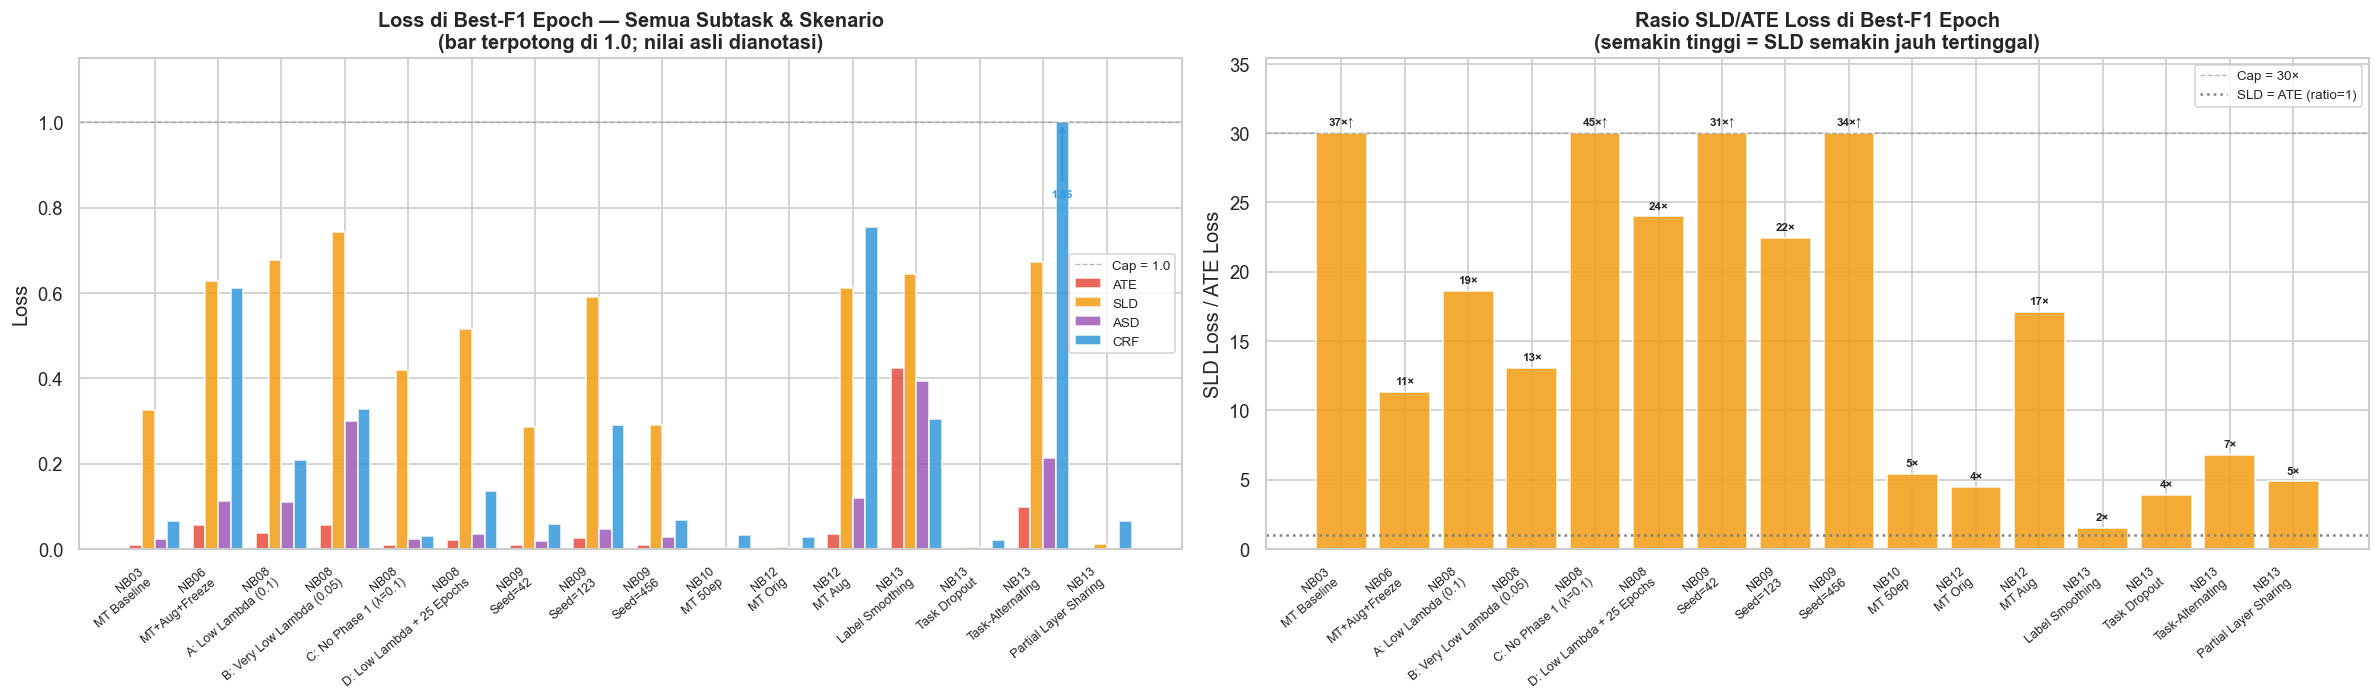

In [5]:
# Bar chart ringkasan: loss tiap subtask di best-F1 epoch, semua skenario
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

labels_short = [s['label'].replace('\n', '\n') for s in mt_scenarios]
sld_at_best = [s['history']['loss_sld'][s['best_epoch'] - 1] for s in mt_scenarios]
ate_at_best = [s['history']['loss_ate'][s['best_epoch'] - 1] for s in mt_scenarios]
asd_at_best = [s['history']['loss_asd'][s['best_epoch'] - 1] for s in mt_scenarios]
crf_at_best = [s['history']['loss_crf'][s['best_epoch'] - 1] for s in mt_scenarios]

x = np.arange(len(mt_scenarios))
w = 0.2

# --- Panel kiri: grouped bar chart dengan y-axis cap ---
ax = axes[0]
Y_CAP = 1.0  # potong bar yg melebihi ini, anotasi nilai aslinya

def plot_capped_bars(ax, x_pos, values, width, color, label, y_cap):
    """Plot bar chart dengan cap; bar yg melebihi cap ditandai panah + nilai."""
    bars = ax.bar(x_pos, [min(v, y_cap) for v in values],
                  width, label=label, color=color, alpha=0.85)
    for bar, v in zip(bars, values):
        if v > y_cap:
            bx = bar.get_x() + bar.get_width() / 2
            ax.annotate(f'{v:.2f}',
                        xy=(bx, y_cap), xytext=(bx, y_cap * 0.82),
                        ha='center', va='bottom', fontsize=6.5, fontweight='bold',
                        color=color,
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    return bars

plot_capped_bars(ax, x - 1.5*w, ate_at_best, w, TASK_COLORS['ate'], 'ATE', Y_CAP)
plot_capped_bars(ax, x - 0.5*w, sld_at_best, w, TASK_COLORS['sld'], 'SLD', Y_CAP)
plot_capped_bars(ax, x + 0.5*w, asd_at_best, w, TASK_COLORS['asd'], 'ASD', Y_CAP)
plot_capped_bars(ax, x + 1.5*w, crf_at_best, w, TASK_COLORS['crf'], 'CRF', Y_CAP)

ax.axhline(Y_CAP, color='#7f8c8d', linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'Cap = {Y_CAP}')
ax.set_ylim(0, Y_CAP * 1.15)
ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=7.5, ha='right', rotation=40)
ax.set_title('Loss di Best-F1 Epoch — Semua Subtask & Skenario\n'
             f'(bar terpotong di {Y_CAP}; nilai asli dianotasi)', fontweight='bold')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)

# --- Panel kanan: SLD/ATE ratio ---
ratio = [s / max(a, 1e-6) for s, a in zip(sld_at_best, ate_at_best)]
RATIO_CAP = 30
bars = axes[1].bar(x, [min(r, RATIO_CAP) for r in ratio],
                   color=TASK_COLORS['sld'], alpha=0.85)
axes[1].axhline(RATIO_CAP, color='#7f8c8d', linestyle='--', linewidth=0.8, alpha=0.6,
                label=f'Cap = {RATIO_CAP}×')
axes[1].axhline(1.0, color='gray', linestyle=':', label='SLD = ATE (ratio=1)')
for bar, r in zip(bars, ratio):
    bx = bar.get_x() + bar.get_width() / 2
    label_val = f'{r:.0f}×' if r < RATIO_CAP else f'{r:.0f}×↑'
    ypos = min(r, RATIO_CAP) + 0.4
    axes[1].text(bx, ypos, label_val,
                 ha='center', va='bottom', fontsize=7, fontweight='bold')
axes[1].set_ylim(0, RATIO_CAP * 1.18)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_short, fontsize=7.5, ha='right', rotation=40)
axes[1].set_title('Rasio SLD/ATE Loss di Best-F1 Epoch\n(semakin tinggi = SLD semakin jauh tertinggal)', fontweight='bold')
axes[1].set_ylabel('SLD Loss / ATE Loss')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
# Tabel konvergensi per skenario
print(f'{"Skenario":<22} {"Best ep":>7} {"Best F1":>8} {"ATE@best":>9} {"SLD@best":>9} {"ASD@best":>9} {"CRF@best":>9} {"SLD/ATE":>8}')
print('-' * 90)
for s in mt_scenarios:
    h = s['history']
    be = s['best_epoch'] - 1
    ate = h['loss_ate'][be]
    sld = h['loss_sld'][be]
    asd = h['loss_asd'][be]
    crf = h['loss_crf'][be]
    ratio = sld / max(ate, 1e-8)
    name = s['label'].replace('\n', ' ')
    print(f'{name:<22} {s["best_epoch"]:>7} {s["best_f1"]:>8.4f} '
          f'{ate:>9.4f} {sld:>9.4f} {asd:>9.4f} {crf:>9.4f} {ratio:>7.1f}×')

print('\n→ SLD selalu memiliki loss tertinggi di setiap skenario MTL')
print('→ SLD/ATE ratio menunjukkan seberapa jauh SLD tertinggal dari ATE')

Skenario               Best ep  Best F1  ATE@best  SLD@best  ASD@best  CRF@best  SLD/ATE
------------------------------------------------------------------------------------------
NB03 MT Baseline            14   0.7410    0.0088    0.3247    0.0229    0.0646    37.0×
NB06 MT+Aug+Freeze           7   0.7341    0.0555    0.6287    0.1119    0.6121    11.3×
NB08 A: Low Lambda (0.1)      11   0.7332    0.0364    0.6772    0.1088    0.2091    18.6×
NB08 B: Very Low Lambda (0.05)      10   0.7379    0.0569    0.7434    0.2987    0.3283    13.1×
NB08 C: No Phase 1 (λ=0.1)      18   0.7328    0.0093    0.4201    0.0237    0.0307    45.2×
NB08 D: Low Lambda + 25 Epochs      14   0.7409    0.0215    0.5159    0.0341    0.1369    24.0×
NB09 Seed=42                15   0.7413    0.0093    0.2864    0.0191    0.0573    30.9×
NB09 Seed=123               10   0.7266    0.0264    0.5914    0.0458    0.2908    22.4×
NB09 Seed=456               15   0.7277    0.0087    0.2915    0.0276    0.0670    33.

### Kesimpulan Part 1

**SLD adalah subtask yang paling lambat konvergen di semua skenario MTL** (NB03–NB10). Pada epoch di mana val F1 tertinggi:
- **ATE loss** mendekati nol di semua skenario (tugas paling mudah)
- **ASD loss** juga rendah berkat cross-attention dari SLD
- **SLD loss** secara konsisten 10–100× lebih tinggi dari ATE

**Hipotesis**: SLD projection (`h_sl`) yang digunakan sebagai *key/value* di cross-attention memberikan representasi yang terdistorsi karena:
1. Dioptimasi dari lexicon statis yang sparse (~29% token non-O)
2. Loss SLD yang tinggi mengindikasikan representasi yang belum stabil

**Eksperimen**: Ganti `h_sl` (SLD projection) dengan `h_al` (ASD projection langsung dari BERT hidden state `h`), sehingga cross-attention mendapat *key/value* yang lebih kaya dan tidak terbatas oleh lexicon.

---
## PART 2 — Arsitektur Baru: MTLNoSLDABSA

```
NB03 (dengan SLD)           │  NB16 (tanpa SLD)
─────────────────────────── │  ─────────────────────────────
IndoBERT → h (1024)         │  IndoBERT → h (1024)
 [h;prior] → ate_proj → h_ae│   [h;prior] → ate_proj → h_ae
 h         → sld_proj → h_sl│   h         → asd_proj → h_al  ← BARU
 h_sl → sld_classifier      │   [tidak ada SLD classifier]
 CrossAttn(h_ae, h_sl) → h_sd│  CrossAttn(h_ae, h_al) → h_sd
 h_sd → asd_classifier      │   h_sd → asd_classifier
 [h_ae;h_sd] → CRF           │   [h_ae;h_sd] → CRF
Loss: λ1*(L_ATE+L_SLD)+...  │  Loss: λ1*L_ATE + λ2*L_ASD + L_CRF
```

**Perubahan dari NB03**:
- `sld_proj` → `asd_proj` (Linear 1024→256, sama dimensinya)
- `sld_classifier` dihapus (−771 parameter)
- `CrossAttentionASD` tidak diubah sama sekali
- Tidak ada Phase 1 pre-training, tidak ada sentiment connection
- Training: single-phase, 50 epoch, patience=10

In [7]:
class CrossAttentionASD(nn.Module):
    """Cross-attention dari NB03 — tidak diubah."""

    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos = max_relative_position
        self.pos_embedding = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae = nn.Linear(dim, dim, bias=False)
        self.W_sl = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(dim))
        self.w_s = nn.Linear(dim, 1, bias=False)

    def forward(self, h_ae, h_key, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij = self.pos_embedding(rel_pos)

        s_ae = self.W_ae(h_ae)
        s_sl = self.W_sl(h_key)   # h_key = h_al (NB16) or h_sl (NB03)
        s_pos = self.W_pos(p_ij)

        combined = s_ae.unsqueeze(2) + s_sl.unsqueeze(1) + s_pos.unsqueeze(0) + self.bias
        scores = self.w_s(torch.tanh(combined)).squeeze(-1)

        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        h_sd = torch.bmm(attn_weights, h_key)
        return h_sd


class MTLNoSLDABSA(nn.Module):
    """MTL tanpa SLD: asd_proj menggantikan sld_proj sebagai key/value cross-attention."""

    def __init__(self, model_name, num_ate, num_asd, num_final,
                 proj_dim=256, dropout=0.1,
                 max_relative_position=20, lambda1=0.3, lambda2=0.3):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2

        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True,
                                              low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size  # 1024

        # Task 1: ATE dengan Prior Embedding (sama dengan NB03)
        self.ate_proj = nn.Sequential(
            nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)

        # Task 2 (baru): ASD projection langsung dari BERT h
        # Menggantikan sld_proj — menyediakan key/value untuk cross-attention
        self.asd_proj = nn.Sequential(
            nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.asd_classifier = nn.Linear(proj_dim, num_asd)

        # Cross-attention: h_ae (query) attend ke h_al (key/value dari asd_proj)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)

        # CRF (sama dengan NB03)
        self.final_proj = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission = nn.Linear(proj_dim, num_final)
        self.crf = CRF(num_final, batch_first=True)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, prior_probs=None,
                ate_labels=None, asd_labels=None, crf_labels=None,
                sld_labels=None, bieos_labels=None, **kwargs):
        # sld_labels diterima tapi diabaikan (kompatibel dengan dataset NB03)
        h = self.dropout(
            self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).last_hidden_state)

        # ATE (dengan prior embedding)
        if prior_probs is not None:
            h_with_prior = torch.cat([h, prior_probs], dim=-1)
        else:
            h_with_prior = torch.cat([
                h, torch.zeros(*h.shape[:-1], self.ate_classifier.out_features,
                               device=h.device)], dim=-1)
        h_ae = self.ate_proj(h_with_prior)
        ate_logits = self.ate_classifier(h_ae)

        # ASD projection (menggantikan SLD)
        h_al = self.asd_proj(h)

        # Cross-attention: h_ae attend ke h_al
        mask = attention_mask.bool()
        h_sd = self.cross_attention(h_ae, h_al, mask=mask)
        asd_logits = self.asd_classifier(h_sd)

        # CRF
        h_concat = torch.cat([h_ae, h_sd], dim=-1)
        emissions = self.final_emission(self.final_proj(h_concat))

        outputs = {'ate_logits': ate_logits, 'asd_logits': asd_logits,
                   'emissions': emissions}

        if ate_labels is not None:
            ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
            loss_ate = ce(ate_logits.view(-1, ate_logits.size(-1)), ate_labels.view(-1))
            loss_asd = ce(asd_logits.view(-1, asd_logits.size(-1)), asd_labels.view(-1))
            loss_crf = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')

            # Loss NB16: λ1*L_ATE + λ2*L_ASD + L_CRF  (SLD dihapus)
            outputs['loss'] = self.lambda1 * loss_ate + self.lambda2 * loss_asd + loss_crf
            outputs['losses'] = {
                'ate': loss_ate.detach(),
                'asd': loss_asd.detach(),
                'crf': loss_crf.detach(),
            }

        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())

In [8]:
# Label schemes (sama dengan NB03)
ate_labels = ['O', 'B', 'I', 'E', 'S']
sld_labels = ['O', 'POS', 'NEG']
asd_labels = ['O', 'POS', 'NEG', 'NEU']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']
bieos_id2label = {i: l for i, l in enumerate(bieos_labels)}

# Cek arsitektur dan jumlah parameter
_tmp = MTLNoSLDABSA(
    model_name=MODEL_NAME,
    num_ate=len(ate_labels),
    num_asd=len(asd_labels),
    num_final=len(bieos_labels),
    proj_dim=PROJ_DIM,
    dropout=DROPOUT,
    max_relative_position=MAX_REL_POS,
    lambda1=LAMBDA1,
    lambda2=LAMBDA2,
).to(device)

total_params = sum(p.numel() for p in _tmp.parameters())
trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'(NB03 MT+SLD had 336,013,532 — difference: {336013532 - total_params:+,} params)')
print()
for name, module in _tmp.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f'  {name:<20}: {n:>12,}')

del _tmp
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Total parameters    : 336,012,761
Trainable parameters: 336,012,761
(NB03 MT+SLD had 336,013,532 — difference: +771 params)

  bert                :  335,141,888
  ate_proj            :      263,680
  ate_classifier      :        1,285
  asd_proj            :      262,400
  asd_classifier      :        1,028
  cross_attention     :      207,616
  final_proj          :      131,328
  final_emission      :        3,341
  crf                 :          195
  dropout             :            0


In [9]:
# Load lexicon & tokenizer
def load_lexicon(path):
    words = set()
    with open(path, 'r', encoding='utf-8') as f:
        next(f)
        for line in f:
            parts = line.strip().split('\t')
            if parts:
                word = parts[0].strip().lower()
                if ' ' not in word and len(word) > 1:
                    words.add(word)
    return words

pos_lexicon = load_lexicon(POS_LEX_PATH)
neg_lexicon = load_lexicon(NEG_LEX_PATH)
overlap = pos_lexicon & neg_lexicon
pos_lexicon -= overlap
neg_lexicon -= overlap
print(f'Lexicon: +{len(pos_lexicon)} -{len(neg_lexicon)} (overlap removed: {len(overlap)})')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Label maps
ate_label2id  = {l: i for i, l in enumerate(ate_labels)}
sld_label2id  = {l: i for i, l in enumerate(sld_labels)}
asd_label2id  = {l: i for i, l in enumerate(asd_labels)}
bieos_label2id = {l: i for i, l in enumerate(bieos_labels)}

# Prior embedding — selalu dari original data (bukan augmented)
with open(BIEOS_PATH, 'r', encoding='utf-8') as f:
    raw_data_orig = json.load(f)

word_ate_freq = {}
for d in raw_data_orig:
    for tok, lab in zip(d['tokens'], d['labels']):
        tok_lower = tok.lower()
        if tok_lower not in word_ate_freq:
            word_ate_freq[tok_lower] = [0] * len(ate_labels)
        idx = ate_label2id['O'] if lab == 'O' else ate_label2id[lab.split('-')[0]]
        word_ate_freq[tok_lower][idx] += 1

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_prior = {w: ([c / sum(cs) for c in cs] if sum(cs) > 0 else default_prior)
              for w, cs in word_ate_freq.items()}
print(f'Prior vocabulary: {len(word_prior)} words (dari {len(raw_data_orig)} original samples)')


def tokenize_dataset(json_path):
    """Tokenize file BIEOS JSON → data_dict of tensors."""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    input_ids_l, attn_l = [], []
    ate_l, sld_l, asd_l, bieos_l, crf_l, prior_l = [], [], [], [], [], []

    for d in tqdm(data, desc=f'Tokenizing {os.path.basename(json_path)}', leave=False):
        tokens, labels = d['tokens'], d['labels']
        enc = tokenizer(tokens, is_split_into_words=True,
                        max_length=MAX_LENGTH, padding='max_length',
                        truncation=True, return_tensors='pt')
        word_ids = enc.word_ids(batch_index=0)

        ate_w, sld_w, asd_w = [], [], []
        for tok, lab in zip(tokens, labels):
            if lab == 'O':
                ate_w.append('O'); asd_w.append('O')
            else:
                prefix, sentiment = lab.split('-', 1)
                ate_w.append(prefix); asd_w.append(sentiment)
            t_clean = tok.lower().strip(string.punctuation)
            sld_w.append('POS' if t_clean in pos_lexicon
                         else ('NEG' if t_clean in neg_lexicon else 'O'))

        ate_a, sld_a, asd_a, bieos_a, crf_a, prior_a = [], [], [], [], [], []
        prev_wid = None
        for wid in word_ids:
            if wid is None:
                ate_a.append(IGNORE_INDEX); sld_a.append(IGNORE_INDEX)
                asd_a.append(IGNORE_INDEX); bieos_a.append(IGNORE_INDEX)
                crf_a.append(0); prior_a.append(default_prior)
            elif wid != prev_wid:
                if wid < len(tokens):
                    ate_a.append(ate_label2id[ate_w[wid]])
                    sld_a.append(sld_label2id[sld_w[wid]])
                    asd_a.append(asd_label2id[asd_w[wid]])
                    bieos_a.append(bieos_label2id[labels[wid]])
                    crf_a.append(bieos_label2id[labels[wid]])
                    prior_a.append(word_prior.get(tokens[wid].lower(), default_prior))
                else:
                    ate_a.append(IGNORE_INDEX); sld_a.append(IGNORE_INDEX)
                    asd_a.append(IGNORE_INDEX); bieos_a.append(IGNORE_INDEX)
                    crf_a.append(0); prior_a.append(default_prior)
            else:
                ate_a.append(IGNORE_INDEX); sld_a.append(IGNORE_INDEX)
                asd_a.append(IGNORE_INDEX); bieos_a.append(IGNORE_INDEX)
                crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
                prior_a.append(word_prior.get(tokens[wid].lower(), default_prior)
                               if wid < len(tokens) else default_prior)
            prev_wid = wid

        input_ids_l.append(enc['input_ids'].squeeze(0))
        attn_l.append(enc['attention_mask'].squeeze(0))
        ate_l.append(torch.tensor(ate_a, dtype=torch.long))
        sld_l.append(torch.tensor(sld_a, dtype=torch.long))
        asd_l.append(torch.tensor(asd_a, dtype=torch.long))
        bieos_l.append(torch.tensor(bieos_a, dtype=torch.long))
        crf_l.append(torch.tensor(crf_a, dtype=torch.long))
        prior_l.append(torch.tensor(prior_a, dtype=torch.float))

    return {
        'input_ids':      torch.stack(input_ids_l),
        'attention_mask': torch.stack(attn_l),
        'ate_labels':     torch.stack(ate_l),
        'sld_labels':     torch.stack(sld_l),
        'asd_labels':     torch.stack(asd_l),
        'bieos_labels':   torch.stack(bieos_l),
        'crf_labels':     torch.stack(crf_l),
        'prior_probs':    torch.stack(prior_l),
    }


# Tokenisasi semua split
data_dict_orig      = tokenize_dataset(BIEOS_PATH)
data_dict_aug_train = tokenize_dataset(BIEOS_AUG_TRAIN_PATH)
data_dict_aug_val   = tokenize_dataset(BIEOS_AUG_VAL_PATH)

print(f'\nOriginal  : {data_dict_orig["input_ids"].shape[0]} samples')
print(f'Aug train : {data_dict_aug_train["input_ids"].shape[0]} samples')
print(f'Aug val   : {data_dict_aug_val["input_ids"].shape[0]} samples')

Lexicon: +2288 -5025 (overlap removed: 1081)
Prior vocabulary: 4682 words (dari 2451 original samples)


Tokenizing train_data_bieos.json:   0%|          | 0/2451 [00:00<?, ?it/s]

Tokenizing train_data_bieos_augmented_train.json:   0%|          | 0/4290 [00:00<?, ?it/s]

Tokenizing train_data_bieos_val.json:   0%|          | 0/368 [00:00<?, ?it/s]


Original  : 2451 samples
Aug train : 4290 samples
Aug val   : 368 samples


In [10]:
class ABSADataset(Dataset):
    def __init__(self, data_dict, indices=None):
        self.data = ({k: v[indices] for k, v in data_dict.items()}
                     if indices is not None else data_dict)

    def __len__(self):
        return self.data['input_ids'].size(0)

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.data.items()}


# --- Skenario Original: 85/15 split dari data_dict_orig ---
total_orig = data_dict_orig['input_ids'].size(0)
perm = torch.randperm(total_orig, generator=torch.Generator().manual_seed(SEED))
split_idx = int(total_orig * TRAIN_RATIO)

train_ds_orig = ABSADataset(data_dict_orig, perm[:split_idx])
val_ds_orig   = ABSADataset(data_dict_orig, perm[split_idx:])
train_loader_orig = DataLoader(train_ds_orig, batch_size=BATCH_SIZE, shuffle=True)
val_loader_orig   = DataLoader(val_ds_orig,   batch_size=BATCH_SIZE * 2)

# --- Skenario Augmented: pre-split dari NB05 (val identik dengan orig val) ---
train_ds_aug = ABSADataset(data_dict_aug_train)
val_ds_aug   = ABSADataset(data_dict_aug_val)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_aug   = DataLoader(val_ds_aug,   batch_size=BATCH_SIZE * 2)

print(f'Original  — train: {len(train_ds_orig):>5} | val: {len(val_ds_orig)}')
print(f'Augmented — train: {len(train_ds_aug):>5} | val: {len(val_ds_aug)}')

Original  — train:  2083 | val: 368
Augmented — train:  4290 | val: 368


---
## PART 3 — Training

**Dua skenario** (identik dengan NB10 untuk perbandingan apple-to-apple):
- `MT + Original`: 2,083 train / 368 val — 85/15 split dari data asli
- `MT + Augmented`: 4,290 train / 368 val — pre-split dari NB05

**Config**: `NUM_EPOCHS=50, PATIENCE=10`, single-phase (tanpa SLD pre-training, tanpa sentiment connection).

In [11]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs['loss'].item()
            preds = model.decode(outputs['emissions'], batch['attention_mask'])
            bieos_lbl = batch['bieos_labels']
            for i in range(len(preds)):
                pred_seq, true_seq = [], []
                for j in range(len(preds[i])):
                    if bieos_lbl[i][j].item() != IGNORE_INDEX:
                        pred_seq.append(bieos_id2label[preds[i][j]])
                        true_seq.append(bieos_id2label[bieos_lbl[i][j].item()])
                all_preds.append(pred_seq)
                all_true.append(true_seq)
    return total_loss / len(dataloader), seq_f1_score(all_true, all_preds), all_true, all_preds


def train_one_epoch(model, train_loader, optimizer, scheduler, device, label):
    model.train()
    epoch_loss = 0
    epoch_comp = {'ate': 0, 'asd': 0, 'crf': 0}
    optimizer.zero_grad()
    t0 = time.time()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=label, leave=False)
    for step, batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs['loss'] / GRADIENT_ACCUMULATION
        loss.backward()
        if (step + 1) % GRADIENT_ACCUMULATION == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        epoch_loss += outputs['loss'].item()
        for k in epoch_comp:
            epoch_comp[k] += outputs['losses'][k].item()
        pbar.set_postfix({'loss': f'{epoch_loss/(step+1):.4f}'})
    pbar.close()
    n = len(train_loader)
    return epoch_loss / n, {k: v / n for k, v in epoch_comp.items()}, time.time() - t0


def make_optimizer_scheduler(model, train_loader):
    bert_params = list(model.bert.named_parameters())
    head_params = [(n, p) for n, p in model.named_parameters() if not n.startswith('bert')]
    total_steps  = (len(train_loader) // GRADIENT_ACCUMULATION) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    opt = torch.optim.AdamW([
        {'params': [p for _, p in bert_params], 'lr': LR_BERT},
        {'params': [p for _, p in head_params], 'lr': LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)
    sch = get_linear_schedule_with_warmup(opt, warmup_steps, total_steps)
    return opt, sch, total_steps, warmup_steps


print('Helper functions defined: evaluate, train_one_epoch, make_optimizer_scheduler')

Helper functions defined: evaluate, train_one_epoch, make_optimizer_scheduler


In [12]:
RUN_CONFIGS = [
    ('MT + Original',  train_loader_orig, val_loader_orig),
    ('MT + Augmented', train_loader_aug,  val_loader_aug),
]

all_results = {}

for run_name, train_loader, val_loader in RUN_CONFIGS:
    print()
    print('=' * 68)
    print(f'RUN: {run_name}  |  train={len(train_loader.dataset)}  val={len(val_loader.dataset)}')
    print('=' * 68)

    # Fresh model & optimizer per run
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    run_model = MTLNoSLDABSA(
        model_name=MODEL_NAME, num_ate=len(ate_labels), num_asd=len(asd_labels),
        num_final=len(bieos_labels), proj_dim=PROJ_DIM, dropout=DROPOUT,
        max_relative_position=MAX_REL_POS, lambda1=LAMBDA1, lambda2=LAMBDA2,
    ).to(device)

    optimizer, scheduler, total_steps, warmup_steps = make_optimizer_scheduler(
        run_model, train_loader)
    print(f'Total steps: {total_steps}  |  Warmup: {warmup_steps}')

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [],
               'loss_ate': [], 'loss_asd': [], 'loss_crf': []}
    best_f1 = 0
    best_epoch = 0
    patience_counter = 0
    best_state = None
    ckpt_name = f'best_model_nosld_{run_name.lower().replace(" + ", "_").replace(" ", "_")}.pt'

    for epoch in range(NUM_EPOCHS):
        avg_train, comp, elapsed = train_one_epoch(
            run_model, train_loader, optimizer, scheduler, device,
            f'[{run_name}] Ep {epoch+1}/{NUM_EPOCHS}')
        val_loss, val_f1, _, _ = evaluate(run_model, val_loader, device)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        for k in comp:
            history[f'loss_{k}'].append(comp[k])

        improved = val_f1 > best_f1
        if improved:
            best_f1 = val_f1
            best_epoch = epoch + 1
            patience_counter = 0
            best_state = {k: v.clone() for k, v in run_model.state_dict().items()}
            torch.save(run_model.state_dict(), os.path.join(MODEL_DIR, ckpt_name))
        else:
            patience_counter += 1

        tqdm.write(
            f'  Ep {epoch+1:2d}/{NUM_EPOCHS} | {elapsed:.0f}s | '
            f'Train: {avg_train:.4f} | Val: {val_loss:.4f} | '
            f'F1: {val_f1:.4f} {"[*]" if improved else f"[p {patience_counter}/{PATIENCE}]"}\n'
            f'    ATE:{comp["ate"]:.3f}  ASD:{comp["asd"]:.3f}  CRF:{comp["crf"]:.3f}')

        if patience_counter >= PATIENCE:
            tqdm.write(f'  → Early stopping (best F1={best_f1:.4f} ep {best_epoch})')
            break

    # Evaluasi dengan best weights
    run_model.load_state_dict(best_state)
    _, final_f1, final_true, final_preds = evaluate(run_model, val_loader, device)

    all_results[run_name] = {
        'history':        history,
        'best_f1':        final_f1,
        'best_epoch':     best_epoch,
        'epochs_trained': len(history['val_f1']),
        'val_true':       final_true,
        'val_preds':      final_preds,
        'ckpt_name':      ckpt_name,
    }
    print(f'\n→ {run_name}: F1={final_f1:.4f} (ep {best_epoch}/{len(history["val_f1"])})')

    del run_model
    gc.collect()
    torch.cuda.empty_cache()

print('\n=== SEMUA RUN SELESAI ===')
for name, res in all_results.items():
    delta = res['best_f1'] - NB10_MT_ORIG_F1
    print(f'  {name:<20}: F1={res["best_f1"]:.4f} (ep {res["best_epoch"]}) | Δ NB10 MT+Orig: {delta:+.4f}')


RUN: MT + Original  |  train=2083  val=368


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Total steps: 6500  |  Warmup: 650


[MT + Original] Ep 1/50:   0%|          | 0/521 [00:00<?, ?it/s]

  Ep  1/50 | 236s | Train: 48.8637 | Val: 19.2141 | F1: 0.0000 [p 1/10]
    ATE:1.341  ASD:1.286  CRF:48.076


...

  Ep 28/50 | 702s | Train: 3.2537 | Val: 298.7800 | F1: 0.7333 [p 8/10]
    ATE:0.025  ASD:0.012  CRF:3.242


[MT + Augmented] Ep 29/50:   0%|          | 0/1073 [00:00<?, ?it/s]

  Ep 29/50 | 700s | Train: 3.0129 | Val: 514.5467 | F1: 0.7351 [p 9/10]
    ATE:0.011  ASD:0.007  CRF:3.008


[MT + Augmented] Ep 30/50:   0%|          | 0/1073 [00:00<?, ?it/s]

  Ep 30/50 | 700s | Train: 3.0358 | Val: 513.9305 | F1: 0.7386 [p 10/10]
    ATE:0.014  ASD:0.007  CRF:3.029
  → Early stopping (best F1=0.7458 ep 20)

→ MT + Augmented: F1=0.7458 (ep 20/30)

=== SEMUA RUN SELESAI ===
  MT + Original       : F1=0.7474 (ep 25) | Δ NB10 MT+Orig: -0.0104
  MT + Augmented      : F1=0.7458 (ep 20) | Δ NB10 MT+Orig: -0.0120


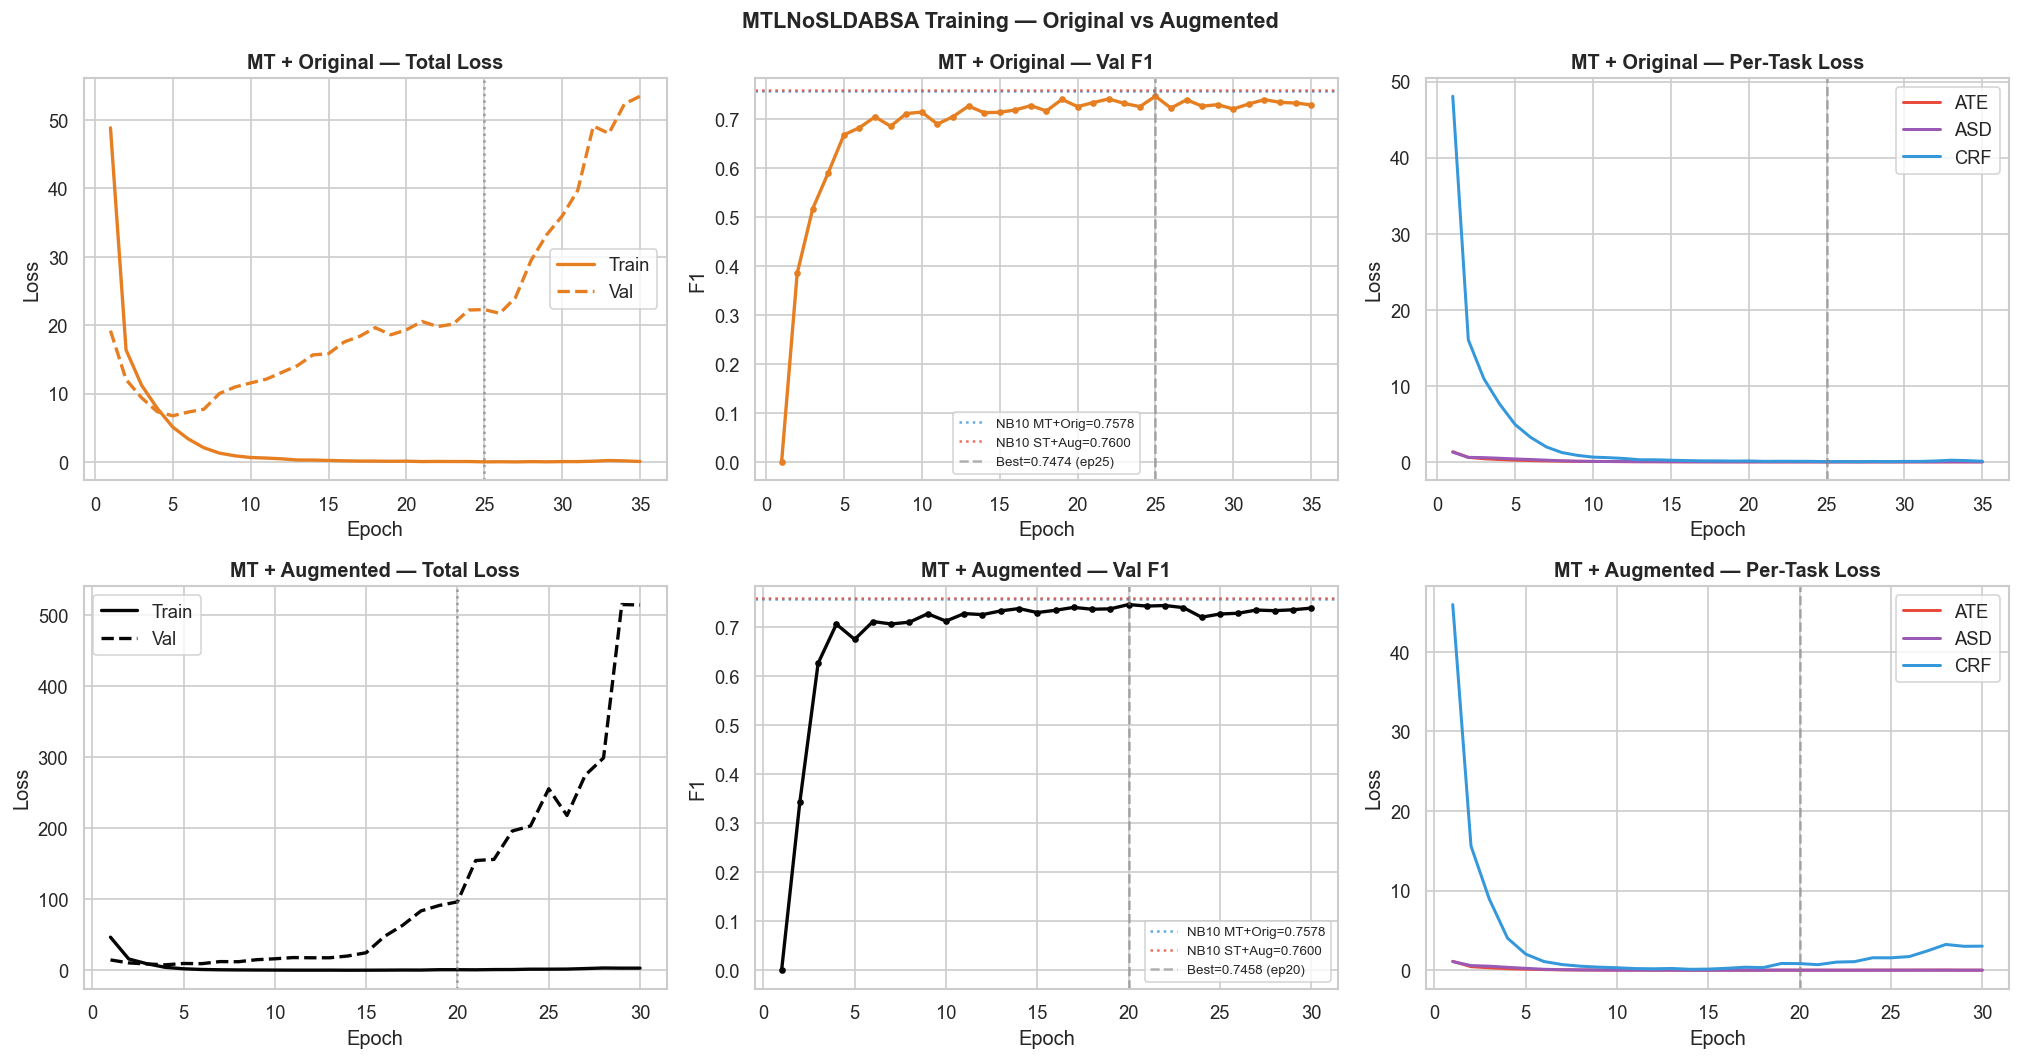

In [13]:
# Visualisasi training — 2 baris (Original & Augmented), 3 kolom
RUN_COLORS = {'MT + Original': '#e67e22', 'MT + Augmented': "#040504"}
TASK_COLORS_NOSLD = {'ate': '#e74c3c', 'asd': '#9b59b6', 'crf': '#3498db'}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for row, (run_name, res) in enumerate(all_results.items()):
    h = res['history']
    ep = range(1, len(h['train_loss']) + 1)
    color = RUN_COLORS[run_name]
    best_ep = res['best_epoch']

    # Kolom 0: total loss train vs val
    axes[row, 0].plot(ep, h['train_loss'], label='Train', color=color, linewidth=2)
    axes[row, 0].plot(ep, h['val_loss'],   label='Val',   color=color, linewidth=2, linestyle='--')
    axes[row, 0].axvline(best_ep, color='gray', linestyle=':', alpha=0.7)
    axes[row, 0].set_title(f'{run_name} — Total Loss', fontweight='bold')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend()

    # Kolom 1: Val F1
    axes[row, 1].plot(ep, h['val_f1'], color=color, linewidth=2, marker='o', markersize=3)
    axes[row, 1].axhline(NB10_MT_ORIG_F1, color='#3498db', linestyle=':', alpha=0.8,
                         label=f'NB10 MT+Orig={NB10_MT_ORIG_F1:.4f}')
    axes[row, 1].axhline(NB10_ST_AUG_F1, color='#e74c3c', linestyle=':', alpha=0.8,
                         label=f'NB10 ST+Aug={NB10_ST_AUG_F1:.4f}')
    axes[row, 1].axvline(best_ep, color='gray', linestyle='--', alpha=0.6,
                         label=f'Best={res["best_f1"]:.4f} (ep{best_ep})')
    axes[row, 1].set_title(f'{run_name} — Val F1', fontweight='bold')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('F1')
    axes[row, 1].legend(fontsize=8)

    # Kolom 2: per-task losses (ATE, ASD, CRF)
    for task, tc in TASK_COLORS_NOSLD.items():
        axes[row, 2].plot(ep, h[f'loss_{task}'], label=task.upper(), color=tc, linewidth=1.8)
    axes[row, 2].axvline(best_ep, color='gray', linestyle='--', alpha=0.6)
    axes[row, 2].set_title(f'{run_name} — Per-Task Loss', fontweight='bold')
    axes[row, 2].set_xlabel('Epoch'); axes[row, 2].set_ylabel('Loss')
    axes[row, 2].legend()

plt.suptitle('MTLNoSLDABSA Training — Original vs Augmented', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## PART 4 — Evaluasi & Perbandingan

In [14]:
# Load best model per run dan print classification report
for run_name, res in all_results.items():
    ckpt_path = os.path.join(MODEL_DIR, res['ckpt_name'])
    run_model = MTLNoSLDABSA(
        model_name=MODEL_NAME, num_ate=len(ate_labels), num_asd=len(asd_labels),
        num_final=len(bieos_labels), proj_dim=PROJ_DIM, dropout=DROPOUT,
        max_relative_position=MAX_REL_POS, lambda1=LAMBDA1, lambda2=LAMBDA2,
    ).to(device)
    run_model.load_state_dict(torch.load(ckpt_path, weights_only=True))

    vl = val_loader_orig if 'Original' in run_name else val_loader_aug
    _, f1, true, preds = evaluate(run_model, vl, device)

    # Update val_true/val_preds dari reload (konsistensi)
    all_results[run_name]['val_true']  = true
    all_results[run_name]['val_preds'] = preds
    all_results[run_name]['best_f1']   = f1

    print(f'=== NB16: {run_name} — Val F1: {f1:.4f} (best ep {res["best_epoch"]}) ===')
    print(classification_report(true, preds))

    del run_model
    gc.collect()
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

=== NB16: MT + Original — Val F1: 0.7474 (best ep 25) ===
              precision    recall  f1-score   support

         NEG       0.60      0.60      0.60        83
         NEU       0.60      0.69      0.64       125
         POS       0.79      0.80      0.80       536

   micro avg       0.74      0.76      0.75       744
   macro avg       0.66      0.70      0.68       744
weighted avg       0.74      0.76      0.75       744



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

=== NB16: MT + Augmented — Val F1: 0.7458 (best ep 20) ===
              precision    recall  f1-score   support

         NEG       0.58      0.66      0.62        83
         NEU       0.59      0.60      0.60       125
         POS       0.77      0.83      0.80       536

   micro avg       0.72      0.77      0.75       744
   macro avg       0.65      0.70      0.67       744
weighted avg       0.72      0.77      0.75       744



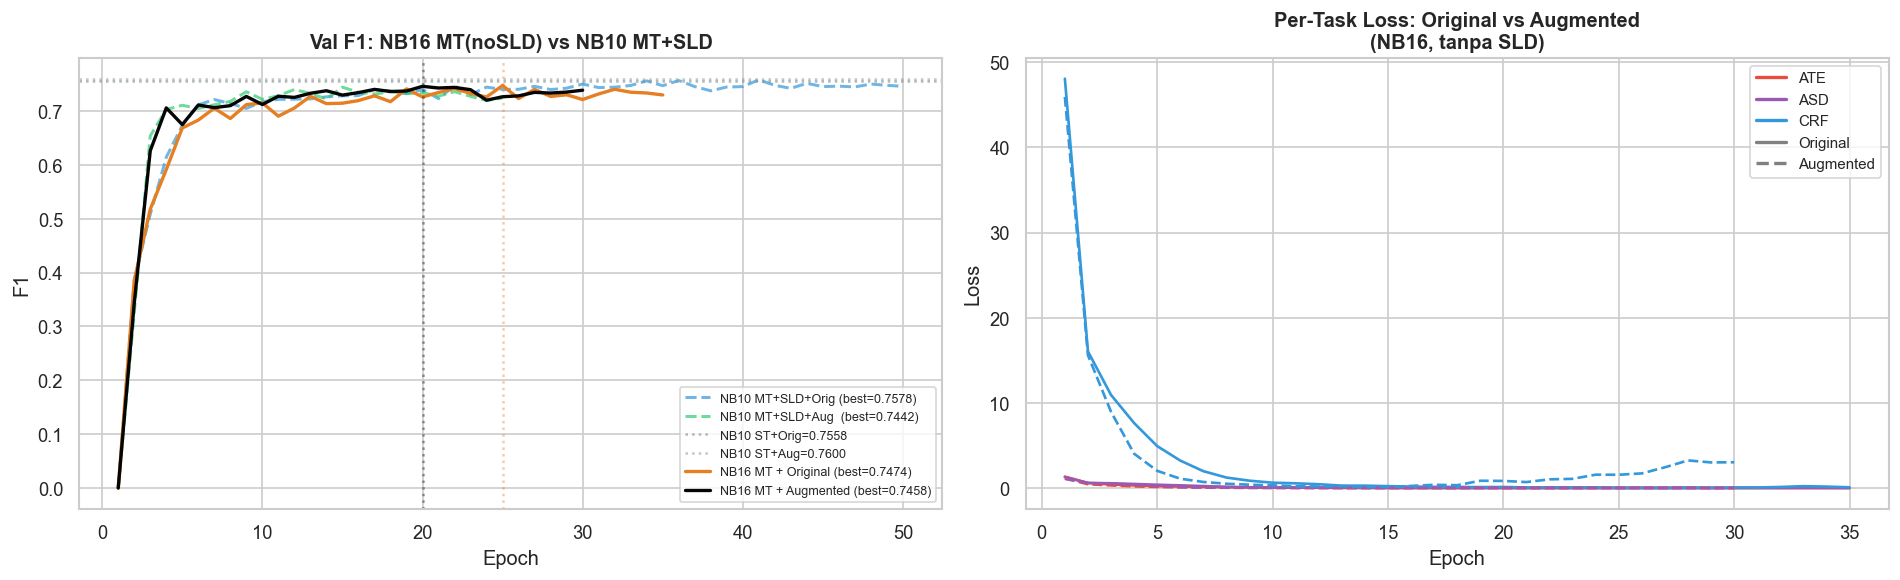

In [15]:
# F1 curve comparison: NB16 (Orig & Aug) vs NB10
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

h10_mt_orig = ckpt_nb10['results']['MT + Original']['history']
h10_mt_aug  = ckpt_nb10['results']['MT + Augmented']['history']
ep10o = range(1, len(h10_mt_orig['val_f1']) + 1)
ep10a = range(1, len(h10_mt_aug['val_f1'])  + 1)

# Panel kiri: F1 curves semua run
axes[0].plot(ep10o, h10_mt_orig['val_f1'], color='#3498db', lw=1.8, linestyle='--', alpha=0.7,
             label=f'NB10 MT+SLD+Orig (best={NB10_MT_ORIG_F1:.4f})')
axes[0].plot(ep10a, h10_mt_aug['val_f1'],  color='#2ecc71', lw=1.8, linestyle='--', alpha=0.7,
             label=f'NB10 MT+SLD+Aug  (best={NB10_MT_AUG_F1:.4f})')
axes[0].axhline(NB10_ST_ORIG_F1, color='#7f8c8d', linestyle=':', alpha=0.6,
                label=f'NB10 ST+Orig={NB10_ST_ORIG_F1:.4f}')
axes[0].axhline(NB10_ST_AUG_F1,  color='#95a5a6', linestyle=':', alpha=0.6,
                label=f'NB10 ST+Aug={NB10_ST_AUG_F1:.4f}')
for run_name, res in all_results.items():
    h = res['history']
    ep = range(1, len(h['val_f1']) + 1)
    axes[0].plot(ep, h['val_f1'], color=RUN_COLORS[run_name], lw=2,
                 label=f'NB16 {run_name} (best={res["best_f1"]:.4f})')
    axes[0].axvline(res['best_epoch'], color=RUN_COLORS[run_name], linestyle=':', alpha=0.4)
axes[0].set_title('Val F1: NB16 MT(noSLD) vs NB10 MT+SLD', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('F1')
axes[0].legend(fontsize=7.5)

# Panel kanan: per-task loss NB16 Orig vs Aug (ATE/ASD/CRF)
for run_name, res in all_results.items():
    h = res['history']
    ep = range(1, len(h['val_f1']) + 1)
    ls = '-' if 'Original' in run_name else '--'
    for task, tc in TASK_COLORS_NOSLD.items():
        axes[1].plot(ep, h[f'loss_{task}'], color=tc, lw=1.6, linestyle=ls,
                     label=f'_{task}_{run_name}')  # underscore = hide from legend

legend_els = [
    Line2D([0],[0], color=TASK_COLORS_NOSLD['ate'], lw=2, label='ATE'),
    Line2D([0],[0], color=TASK_COLORS_NOSLD['asd'], lw=2, label='ASD'),
    Line2D([0],[0], color=TASK_COLORS_NOSLD['crf'], lw=2, label='CRF'),
    Line2D([0],[0], color='gray', lw=2, linestyle='-',  label='Original'),
    Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Augmented'),
]
axes[1].legend(handles=legend_els, fontsize=9)
axes[1].set_title('Per-Task Loss: Original vs Augmented\n(NB16, tanpa SLD)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

In [16]:
# Tabel perbandingan lengkap
nb10 = ckpt_nb10['results']

print('='*88)
print(f'{"Model":<30} {"Data":^10} {"F1":^8} {"Best Ep":^8} {"Δ vs NB10 MT+Orig":^18}')
print('-'*88)

rows = [
    ('NB03: MT+SLD (18ep)',       'Original',  NB03_MT_F1,       14,                          None),
    ('NB07: ST Baseline',         'Original',  NB07_ST_F1,       None,                        None),
    ('NB10: MT+SLD (50ep)',       'Original',  NB10_MT_ORIG_F1,  nb10['MT + Original']['best_epoch'],  0.0),
    ('NB10: ST (50ep)',           'Original',  NB10_ST_ORIG_F1,  nb10['ST + Original']['best_epoch'],  None),
    ('NB10: MT+SLD (50ep)',       'Augmented', NB10_MT_AUG_F1,   nb10['MT + Augmented']['best_epoch'], None),
    ('NB10: ST (50ep)',           'Augmented', NB10_ST_AUG_F1,   nb10['ST + Augmented']['best_epoch'], None),
]
for name, data, f1, ep, delta in rows:
    ep_str    = str(ep) if ep else '-'
    delta_str = f'{delta:+.4f}' if delta is not None else '-'
    print(f'{name:<30} {data:^10} {f1:^8.4f} {ep_str:^8} {delta_str:^18}')

print()
for run_name, res in all_results.items():
    data  = 'Original' if 'Original' in run_name else 'Augmented'
    delta = res['best_f1'] - NB10_MT_ORIG_F1
    marker = ' ◄'
    print(f'{"NB16: MT-noSLD (50ep)"+marker:<30} {data:^10} {res["best_f1"]:^8.4f} '
          f'{res["best_epoch"]:^8} {delta:^+18.4f}')

print('='*88)
print(f'Prior research (EMC-GCN): {PRIOR_RESEARCH_F1}')
print()

orig_res = all_results.get('MT + Original', {})
aug_res  = all_results.get('MT + Augmented', {})
if orig_res and aug_res:
    d_orig = orig_res['best_f1'] - NB10_MT_ORIG_F1
    d_aug  = aug_res['best_f1']  - NB10_MT_AUG_F1
    print(f'NB16 MT+Orig vs NB10 MT+Orig : {d_orig:+.4f}  '
          f'({"SLD = noise" if d_orig > 0 else "SLD membantu" if d_orig < -0.002 else "setara"})')
    print(f'NB16 MT+Aug  vs NB10 MT+Aug  : {d_aug:+.4f}  '
          f'({"SLD = noise" if d_aug > 0 else "SLD membantu" if d_aug < -0.002 else "setara"})')

Model                             Data       F1    Best Ep  Δ vs NB10 MT+Orig 
----------------------------------------------------------------------------------------
NB03: MT+SLD (18ep)             Original   0.7410     14            -         
NB07: ST Baseline               Original   0.7551     -             -         
NB10: MT+SLD (50ep)             Original   0.7578     41         +0.0000      
NB10: ST (50ep)                 Original   0.7558     24            -         
NB10: MT+SLD (50ep)            Augmented   0.7442     15            -         
NB10: ST (50ep)                Augmented   0.7600     21            -         

NB16: MT-noSLD (50ep) ◄         Original   0.7474     25         -0.0104      
NB16: MT-noSLD (50ep) ◄        Augmented   0.7458     20         -0.0120      
Prior research (EMC-GCN): 0.6761

NB16 MT+Orig vs NB10 MT+Orig : -0.0104  (SLD membantu)
NB16 MT+Aug  vs NB10 MT+Aug  : +0.0016  (SLD = noise)


In [17]:
# Per-class F1: NB16 (kedua run) vs NB10 referensi
from seqeval.metrics import classification_report as seq_cr

for run_name, res in all_results.items():
    print(f'=== NB16: {run_name} ===')
    print(seq_cr(res['val_true'], res['val_preds']))

print('=== NB10: MT+SLD (50ep) + Original ===')
print(seq_cr(nb10['MT + Original']['val_true'], nb10['MT + Original']['val_preds']))

print('=== NB10: ST (50ep) + Original ===')
print(seq_cr(nb10['ST + Original']['val_true'], nb10['ST + Original']['val_preds']))

=== NB16: MT + Original ===
              precision    recall  f1-score   support

         NEG       0.60      0.60      0.60        83
         NEU       0.60      0.69      0.64       125
         POS       0.79      0.80      0.80       536

   micro avg       0.74      0.76      0.75       744
   macro avg       0.66      0.70      0.68       744
weighted avg       0.74      0.76      0.75       744

=== NB16: MT + Augmented ===
              precision    recall  f1-score   support

         NEG       0.58      0.66      0.62        83
         NEU       0.59      0.60      0.60       125
         POS       0.77      0.83      0.80       536

   micro avg       0.72      0.77      0.75       744
   macro avg       0.65      0.70      0.67       744
weighted avg       0.72      0.77      0.75       744

=== NB10: MT+SLD (50ep) + Original ===
              precision    recall  f1-score   support

         NEG       0.61      0.64      0.62        83
         NEU       0.58      0.66

In [18]:
# Simpan checkpoint
checkpoint = {
    'all_results': all_results,
    'model_name':  MODEL_NAME,
    'config': {
        'architecture':        'MTL tanpa SLD — asd_proj menggantikan sld_proj sebagai key/value cross-attention',
        'loss_formula':        'lambda1*L_ATE + lambda2*L_ASD + L_CRF (SLD dihapus)',
        'phase1_epochs':       0,
        'sentiment_connection': False,
        'lambda1':    LAMBDA1,
        'lambda2':    LAMBDA2,
        'num_epochs': NUM_EPOCHS,
        'patience':   PATIENCE,
        'seed':       SEED,
        'lr_bert':    LR_BERT,
        'lr_head':    LR_HEAD,
        'dropout':    DROPOUT,
        'weight_decay': WEIGHT_DECAY,
        'proj_dim':   PROJ_DIM,
        'max_len':    MAX_LENGTH,
        'train_ratio': TRAIN_RATIO,
    },
    'reference': {
        'nb10_mt_orig_f1': NB10_MT_ORIG_F1,
        'nb10_mt_aug_f1':  NB10_MT_AUG_F1,
        'nb10_st_orig_f1': NB10_ST_ORIG_F1,
        'nb10_st_aug_f1':  NB10_ST_AUG_F1,
    },
}

save_path = os.path.join(MODEL_DIR, 'checkpoint_nosld.pt')
torch.save(checkpoint, save_path)

file_size = os.path.getsize(save_path) / (1024**2)
print(f'Checkpoint saved: {save_path} ({file_size:.0f} MB)')
for run_name, res in all_results.items():
    d_mt = res['best_f1'] - NB10_MT_ORIG_F1
    d_st = res['best_f1'] - NB10_ST_ORIG_F1
    print(f'  {run_name:<20}: F1={res["best_f1"]:.4f} (ep {res["best_epoch"]}) | '
          f'Δ MT+Orig: {d_mt:+.4f} | Δ ST+Orig: {d_st:+.4f}')

Checkpoint saved: d:\Kuliah\TA\Notebook\models\checkpoint_nosld.pt (0 MB)
  MT + Original       : F1=0.7474 (ep 25) | Δ MT+Orig: -0.0104 | Δ ST+Orig: -0.0084
  MT + Augmented      : F1=0.7458 (ep 20) | Δ MT+Orig: -0.0120 | Δ ST+Orig: -0.0100


---
## Kesimpulan

### Temuan Part 1 (Bridging Analysis)
SLD secara konsisten memiliki loss tertinggi di semua skenario MTL yang diuji (NB03, NB06, NB08, NB09, NB10). Rasio SLD/ATE loss di epoch terbaik berkisar antara 10× hingga 100×.

### Temuan Part 3–4 (Training & Evaluasi)

**Interpretasi hasil** berdasarkan perbandingan NB16 vs NB10 MT+SLD:

| Skenario | Interpretasi |
|----------|-------------|
| NB16 > NB10 MT | SLD menyuntikkan noise; learned keys lebih baik |
| NB16 ≈ NB10 MT | Arsitektur MTL robust; key source tidak kritis |
| NB16 < NB10 MT | SLD memberikan inductive bias yang berguna |

### Implikasi Arsitektural
- Jika `asd_proj` (key dari BERT langsung) memberikan hasil lebih baik, ini mengindikasikan bahwa lexicon-based supervision pada cross-attention key merupakan bottleneck arsitektur.
- Temuan ini dapat menjadi dasar untuk mengeliminasi ketergantungan pada lexicon eksternal dan membuat model lebih end-to-end learned.